# ML - Aprendizaje No Supervisado

ESTUDIANTE: VALDA PLAZA CAMILA MONSERRAT.
CARRERA; INGENIERA DE SISTEMAS.

DATASET QUE TRATA SOBRE CANCIONES REALES DONDE FUERON OBTENIDAS DE LA API SPOTIFY WEB.

## Clustering

De entre las diferentes técnicas de aprendizaje no supervisado, el *Clustering* es una de las más usadas. Este técnica consiste en identificar aquellas muestras similares del conjunto de datos y asignarlas a un *cluster*, o grupo. Esto permite aplicaciones tales como: segmentación de clientes, análisis de datos, reducción de la dimensionalidad, detección de anomalías, aprendizaje semi-supervisado, motores de búsqueda e incluso la semgentación de imágenes.

### K-Means

El algoritmo de *K-Means* es uno de los más usados a la hora de aplicar *Clustering*, ya que es un método rápido y eficiente. Vamos a generar un conjunto de datos sintético para aprender a usar esta técnica.

In [38]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import pandas as pd


df = pd.read_csv("/content/drive/MyDrive/dataset corregido/Spotify_limpio_sinpopularidad.csv")

features = ['danceability', 'energy', 'key', 'loudness', 'mode',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo', 'duration_ms']
X = df[features].values

print("Shape de X:", X.shape)
print("Primeras filas:")
print(df[features].head())

Shape de X: (130663, 12)
Primeras filas:
   danceability  energy  key  loudness  mode  speechiness  acousticness  \
0         0.743   0.339    1    -7.678     1       0.4090      0.005820   
1         0.846   0.557    8    -7.259     1       0.4570      0.024400   
2         0.603   0.723    9    -5.890     0       0.0454      0.025000   
3         0.800   0.579    5   -12.118     0       0.0701      0.029400   
4         0.783   0.792    7   -10.277     1       0.0661      0.000035   

   instrumentalness  liveness  valence    tempo  duration_ms  
0             0.000    0.0812    0.118  203.927       238373  
1             0.000    0.2860    0.371  159.009       214800  
2             0.000    0.0824    0.382  114.966       138913  
3             0.912    0.0994    0.641  123.003       125381  
4             0.878    0.0332    0.928  120.047       124016  


In [40]:
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df_plot = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print(df_plot.head())

            PC1        PC2
0  25739.875700  84.520775
1   2166.875806  39.630424
2 -73720.124091  -4.468942
3 -87252.124104   3.206364
4 -88617.124099   0.346162


In [41]:
import numpy as np
import random

X_2d = df_plot[['PC1', 'PC2']].values

n_centers = random.randint(2, 10)

blob_centers = []
while len(blob_centers) < n_centers:
    candidate = X_2d[np.random.randint(0, len(X_2d))]
    if all(np.linalg.norm(candidate - center) > 0.5 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.unique(np.array(blob_centers), axis=0)

blob_std = np.full(len(blob_centers), 0.7)

print(f"Se generaron {len(blob_centers)} centroides aleatorios a partir de los datos")
print("Coordenadas de los centroides:")
print(blob_centers)


Se generaron 7 centroides aleatorios a partir de los datos
Coordenadas de los centroides:
[[-8.72451240e+04 -2.00564697e+01]
 [-5.25511242e+04  5.52181771e+01]
 [-1.36061241e+04 -1.62502684e+01]
 [-6.12112423e+03  5.46410274e+01]
 [-5.01012410e+03  2.78774240e-01]
 [ 3.69487586e+03  1.49070920e+01]
 [ 9.74278759e+04  1.66851809e+01]]


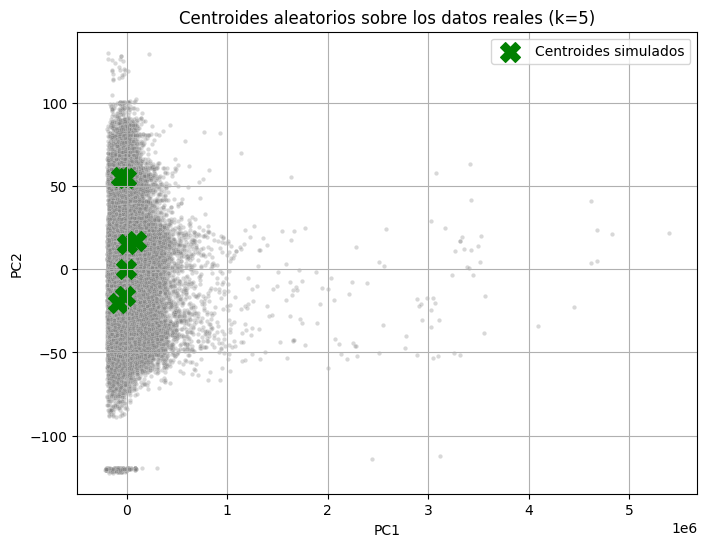

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], color='gray', alpha=0.3, s=10)
plt.scatter(blob_centers[:,0], blob_centers[:,1], c='green', marker='X', s=200, label="Centroides simulados")
plt.title(f"Centroides aleatorios sobre los datos reales (k={k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
from sklearn.cluster import KMeans

k = len(blob_centers)
kmeans = KMeans(n_clusters=k, init=blob_centers, n_init=1, random_state=42)
y_pred = kmeans.fit_predict(X_2d)

In [44]:
kmeans.cluster_centers_

array([[-1.19987203e+05, -6.04268394e+00],
       [-3.42688063e+04,  1.64116832e+00],
       [ 2.55580050e+04,  1.45843365e+00],
       [ 1.25830559e+05, -7.30829174e-01],
       [ 3.31381340e+05, -6.45044003e+00],
       [ 8.99488627e+05, -1.30496961e+01],
       [ 3.07230838e+06, -1.49164117e+01]])

In [45]:

X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])

pred_new = kmeans.predict(X_new)
print("Predicciones para X_new:", pred_new)

distances_new = kmeans.transform(X_new)
print("Distancias a cada centro (X_new x centros):\n", distances_new)

Predicciones para X_new: [2 2 2 2]
Distancias a cada centro (X_new x centros):
 [[ 119987.20332545   34268.80632209   25558.00503312  125830.55938643
   331381.34017871  899488.62675547 3072308.37599446]
 [ 119990.20332544   34271.80632209   25555.00503312  125827.55938643
   331378.34017871  899485.62675547 3072305.37599446]
 [ 119984.20339666   34265.80634715   25561.00507386  125833.5594121
   331384.34020572  899491.62677276 3072311.37600013]
 [ 119984.20336001   34265.80633097   25561.0050486   125833.55939827
   331384.34019184  899491.62676398 3072311.37599726]]


In [46]:
import matplotlib.pyplot as plt
import numpy as np

def plot_data(X):
    plt.scatter(X[:, 0], X[:, 1], c='k', s=6, marker='.', alpha=0.6)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    centroids = np.asarray(centroids)
    if weights is not None:
        weights = np.asarray(weights)
        if len(weights) == len(centroids):
            mask = weights > weights.max() / 10
            centroids = centroids[mask]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=120, linewidths=1,
                facecolors=circle_color, edgecolors='k',
                zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=80, linewidths=2,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=300, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 1.0
    maxs = X.max(axis=0) + 1.0
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clusterer.predict(grid)
    Z = Z.reshape(xx.shape)
    levels = np.arange(Z.max() + 2) - 0.5
    plt.contourf(xx, yy, Z, levels=levels, cmap="Pastel2", alpha=0.8)
    plt.contour(xx, yy, Z, levels=levels, linewidths=0.5, colors='k', alpha=0.5)
    plot_data(X)
    if show_centroids:
        centroids = clusterer.cluster_centers_
        try:
            labels = clusterer.labels_
            counts = np.bincount(labels, minlength=centroids.shape[0])
            plot_centroids(centroids, weights=counts)
        except Exception:
            plot_centroids(centroids)
    if show_xlabels:
        plt.xlabel("$x_1$", fontsize=12)
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", fontsize=12, rotation=0)
    else:
        plt.tick_params(labelleft=False)

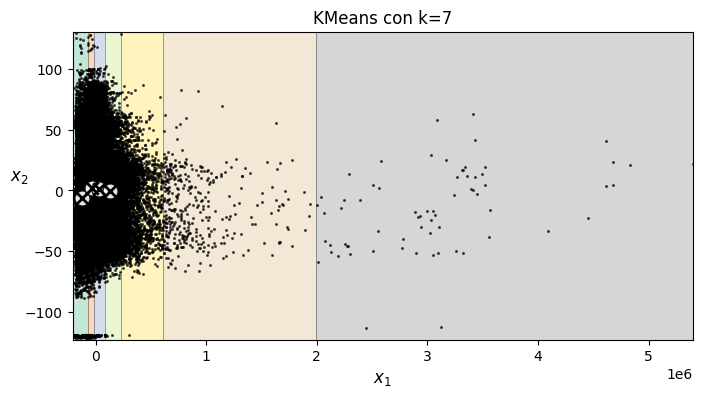

In [47]:
plt.figure(figsize=(8, 4))
if k > 1:
    plot_decision_boundaries(kmeans, X_2d)
else:
    plot_data(X_2d)
    plot_centroids(kmeans.cluster_centers_)
plt.title(f"KMeans con k={k}")
plt.show()

En lugar de asignar un grupo a cada muestra (*hard clustering*) se le puede asignar una puntuación (*soft clustering*) en función de su distancia al centroide.

In [48]:
kmeans.transform(X_new)

array([[ 119987.20332545,   34268.80632209,   25558.00503312,
         125830.55938643,  331381.34017871,  899488.62675547,
        3072308.37599446],
       [ 119990.20332544,   34271.80632209,   25555.00503312,
         125827.55938643,  331378.34017871,  899485.62675547,
        3072305.37599446],
       [ 119984.20339666,   34265.80634715,   25561.00507386,
         125833.5594121 ,  331384.34020572,  899491.62677276,
        3072311.37600013],
       [ 119984.20336001,   34265.80633097,   25561.0050486 ,
         125833.55939827,  331384.34019184,  899491.62676398,
        3072311.37599726]])

Este algoritmo funciona asignando centroides de manera aleatoria y, de manera iterativa, asigna cada instancia a uno de ellos (el más cercano) tras lo cual se recalcula el centroide como el valor promedio de todas las instancias asignadas al grupo.

In [49]:
kmeans_iter1 = KMeans(n_clusters=k, init="k-means++", n_init=1, max_iter=1, random_state=1)
kmeans_iter2 = KMeans(n_clusters=k, init="k-means++", n_init=1, max_iter=2, random_state=1)
kmeans_iter3 = KMeans(n_clusters=k, init="k-means++", n_init=1, max_iter=3, random_state=1)

kmeans_iter1.fit(X_2d)
kmeans_iter2.fit(X_2d)
kmeans_iter3.fit(X_2d)

KMeans(max_iter=3, n_clusters=7, n_init=1, random_state=1)

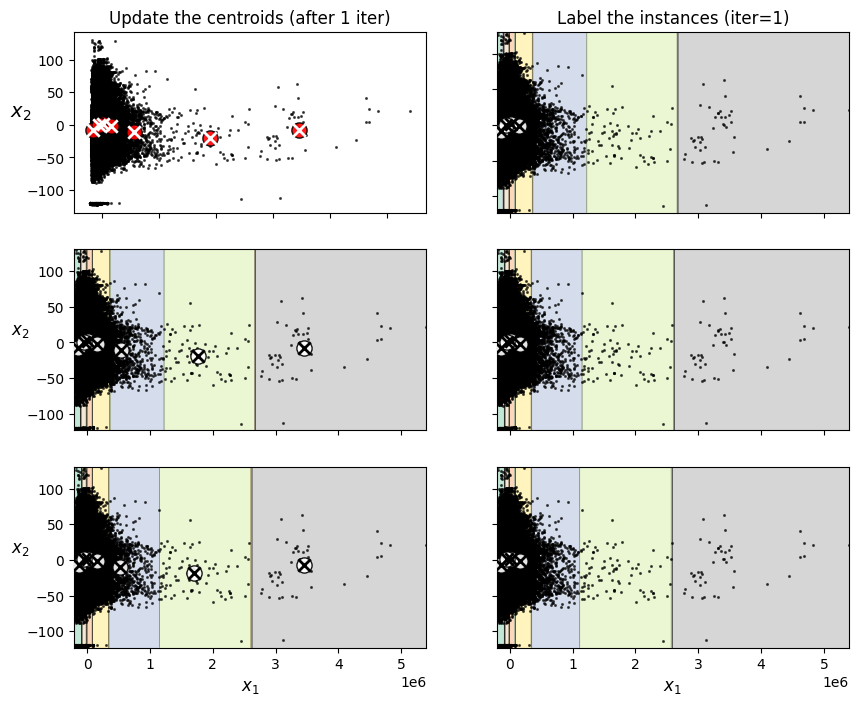

In [50]:
plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X_2d)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", fontsize=14, rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (after 1 iter)", fontsize=12)

plt.subplot(322)
if k > 1:
    plot_decision_boundaries(kmeans_iter1, X_2d, show_xlabels=False, show_ylabels=False)
else:
    plot_data(X_2d)
plt.title("Label the instances (iter=1)", fontsize=12)

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X_2d, show_centroids=False, show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
if k > 1:
    plot_decision_boundaries(kmeans_iter2, X_2d, show_xlabels=False, show_ylabels=False)
else:
    plot_data(X_2d)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X_2d, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
if k > 1:
    plot_decision_boundaries(kmeans_iter3, X_2d, show_ylabels=False)
else:
    plot_data(X_2d)

plt.show()

Esto implica que en función del estado inicial, el algoritmo puede llegar a una solución u otra.

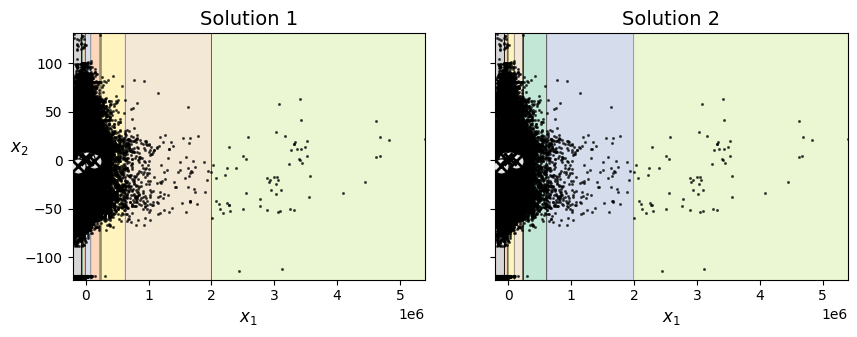

In [51]:

def plot_clusterer_comparison(clusterer1, clusterer2, X_2d, title1=None, title2=None):

    clusterer1.fit(X_2d)
    clusterer2.fit(X_2d)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X_2d)
    if title1:
        plt.title(title1, fontsize=14)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X_2d, show_ylabels=False)
    if title2:
        plt.title(title2, fontsize=14)


kmeans_rnd_init1 = KMeans(n_clusters=k, init="random", n_init=1, random_state=11)
kmeans_rnd_init2 = KMeans(n_clusters=k, init="random", n_init=1, random_state=19)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X_pca, "Solution 1", "Solution 2")
plt.show()

In [52]:

kmeans_rnd_10_inits = KMeans(n_clusters=k, init="random", n_init=10, random_state=11)
kmeans_rnd_10_inits.fit(X_pca)

print("Centroides encontrados:")
print(kmeans_rnd_10_inits.cluster_centers_)

from collections import Counter
print("Tamaño de cada cluster predicho:", Counter(kmeans_rnd_10_inits.labels_))
print("Inercia:", kmeans_rnd_10_inits.inertia_)

Centroides encontrados:
[[-3.38813457e+04  1.63165884e+00]
 [ 1.27047068e+05 -7.15792175e-01]
 [ 2.61485997e+04  1.47189353e+00]
 [ 3.07230838e+06 -1.49164117e+01]
 [ 3.32629784e+05 -6.51966135e+00]
 [ 8.99488627e+05 -1.30496961e+01]
 [-1.19707438e+05 -6.03531386e+00]]
Tamaño de cada cluster predicho: Counter({np.int32(0): 52669, np.int32(2): 43529, np.int32(6): 19510, np.int32(1): 11736, np.int32(4): 2786, np.int32(5): 365, np.int32(3): 68})
Inercia: 175452750694016.38


Para minimizar el impacto de la inicialización tenemos varias alternativas: probar varias y quedarnos con la mejor, o usar la inicialización inteligente que ofrece *Scikit-Learn* por defecto.

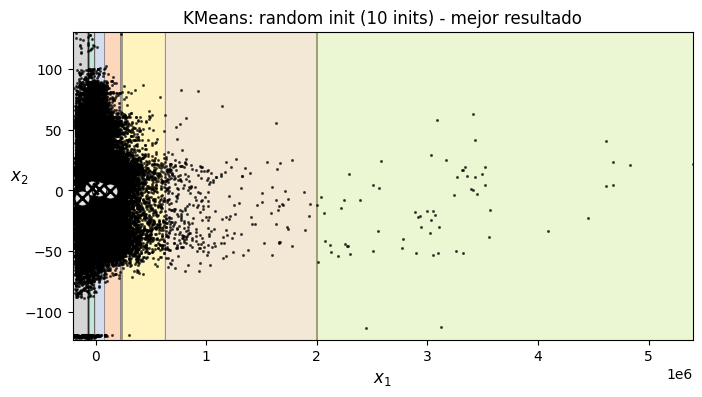

In [53]:
plt.figure(figsize=(8, 4))

if k > 1:
    plot_decision_boundaries(kmeans_rnd_10_inits, X_pca)
else:
    plot_data(X_pca)
    plot_centroids(kmeans_rnd_10_inits.cluster_centers_)

plt.title("KMeans: random init (10 inits) - mejor resultado")
plt.show()

mini-batch K-Means

In [54]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X_2d, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X_train: (97997, 2)
Shape of X_test: (32666, 2)


In [55]:
def load_next_batch(batch_size):
    return X[np.random.choice(len(X), batch_size, replace=False)]

In [56]:
from sklearn.cluster import MiniBatchKMeans

k = 5
n_init = 10
n_iterations = 100
batch_size = 100
init_size = 500
evaluate_on_last_n_iters = 10

best_kmeans = None # aqui creamosS variable para guardar el mejor modelo entrenado
# el entrenamiento de Mini-bacht kmeans
for init in range(n_init):
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, init_size=init_size)
    X_init = load_next_batch(init_size)
    minibatch_kmeans.partial_fit(X_init)

    minibatch_kmeans.sum_inertia_ = 0
    for iteration in range(n_iterations):
        X_batch = load_next_batch(batch_size)
        minibatch_kmeans.partial_fit(X_batch)
        if iteration >= n_iterations - evaluate_on_last_n_iters:
            minibatch_kmeans.sum_inertia_ += minibatch_kmeans.inertia_

    if (best_kmeans is None or
        minibatch_kmeans.sum_inertia_ < best_kmeans.sum_inertia_):
        best_kmeans = minibatch_kmeans

In [57]:
best_kmeans.score(X)

-801023413867122.0

Encontrando el número óptimo de grupos

MÉTODO silhouette_score y MÉTODO DEL CODO:

In [58]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_2d, kmeans.labels_)
print("Silhouette score (k actual):", score)

Silhouette score (k actual): 0.521808154668655


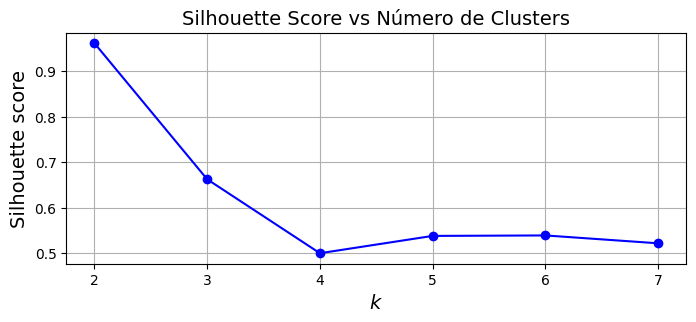

In [59]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

max_k = min(20, len(blob_centers))
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X_2d) for k in range(1, max_k + 1)]
silhouette_scores = [silhouette_score(X_2d, model.labels_) for model in kmeans_per_k[1:]]

ks = list(range(2, max_k + 1))

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouette_scores, "bo-")
plt.xlabel("$k$", fontsize=14)
plt.ylabel("Silhouette score", fontsize=14)
plt.title("Silhouette Score vs Número de Clusters", fontsize=14)
plt.grid(True)
plt.show()

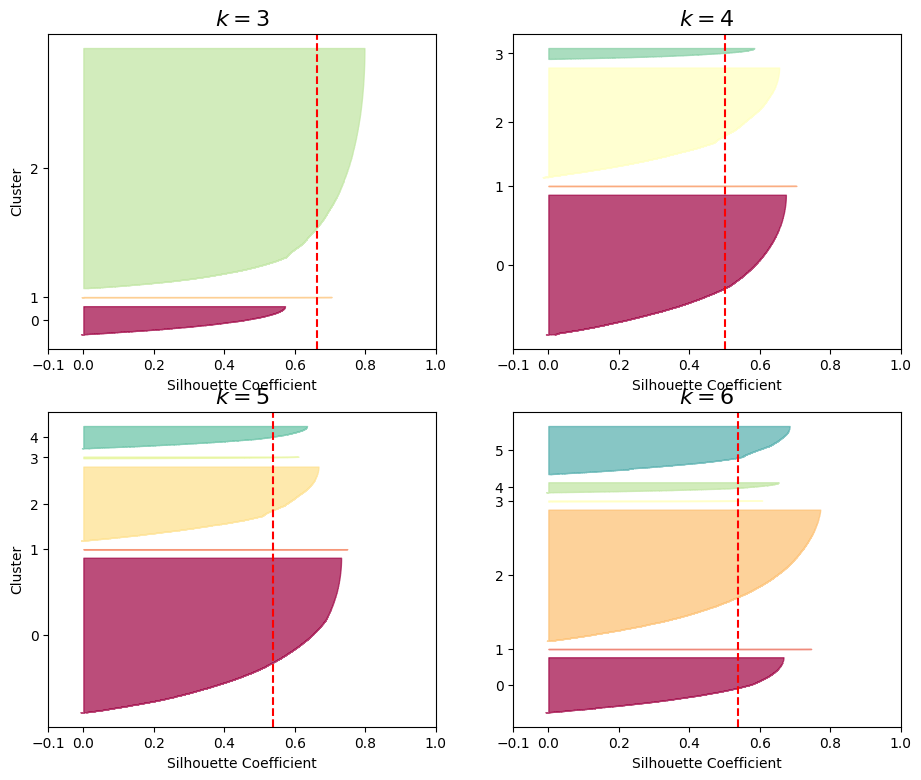

In [60]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl
import numpy as np

plt.figure(figsize=(11, 9))
valid_ks = [k for k in range(3, min(max_k+1, 7))]

for plot_idx, k in enumerate(valid_ks):
    plt.subplot(2, 2, plot_idx + 1)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X_2d, y_pred)

    padding = len(X_2d) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()
        color = mpl.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.xlabel("Silhouette Coefficient")
    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$", fontsize=16)

plt.show()

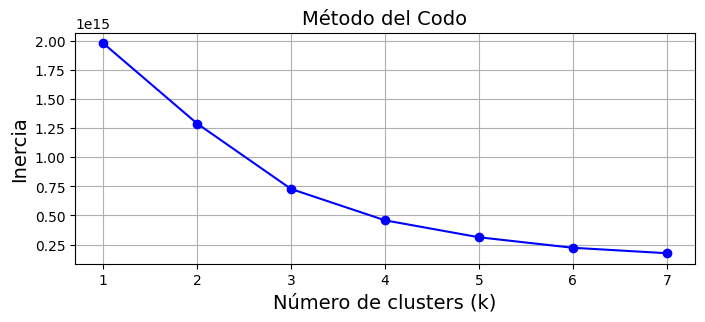

In [61]:
inertias = []
for k in range(1, max_k + 1):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X_2d)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 3))
plt.plot(range(1, max_k + 1), inertias, "bo-")
plt.xlabel("Número de clusters (k)", fontsize=14)
plt.ylabel("Inercia", fontsize=14)
plt.title("Método del Codo", fontsize=14)
plt.grid(True)
plt.show()